# 03. CLRKDNet 공식 inference 후처리 재현

02 노트북에서는 raw proposal을 직접 해석했지만, 결과 이미지에 lane curve가 거의 보이지 않았다.
이번 03 노트북의 목적은 바로 튜닝으로 넘어가는 것이 아니라, **공식 CLRKDNet repo의 inference 후처리를 ONNX 출력 위에서 최대한 재현**하는 것이다.

확인할 핵심은 세 가지다.

1. `score`는 raw value가 아니라 `softmax(pred[:, :2])[:, 1]`로 계산해야 함.
2. `length`는 raw output 그대로 쓰는 값이 아니라 `length * n_strips`로 복원해야 함.
3. CULane 샘플에서 먼저 lane이 그려지는지 확인한 뒤, 같은 후처리를 우리 map 이미지에 적용해야 함.

즉, 이 노트북은 “우리 map에서 안 된다”를 말하기 전에 **모델 출력 해석법이 맞는지 복구하는 단계**다.

## 1. 환경과 파일 경로 확인

이 노트북은 로컬 Windows의 `<env>` 커널 기준으로 실행한다. PyTorch 공식 모델을 직접 실행하는 단계가 아니라, 이미 export된 ONNX 모델의 raw output을 공식 후처리 방식으로 해석한다.

In [1]:
from pathlib import Path
import time
import cv2
import numpy as np
import pandas as pd
import onnxruntime as ort
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
MODEL_DIR = PROJECT_ROOT / "model"
FP32_ONNX = MODEL_DIR / "clrkdnet_resnet18_culane.onnx"
PTQ_ONNX = MODEL_DIR / "clrkdnet_resnet18_culane_static_qoperator_int8.onnx"

CULANE_DIR = PROJECT_ROOT / "CULane_dataset" / "calibration_images_culane_driver37_200"
MAP_RAW = PROJECT_ROOT / "20260430_map_lab" / "20260430_map_lab" / "raw"
LANE_RAW = MAP_RAW / "lane"
BACKGROUND_RAW = MAP_RAW / "signs" / "background"

OUTPUT_DIR = PROJECT_ROOT / "phase3_lane_experiments" / "outputs" / "03_official_inference_reproduction"
OVERLAY_DIR = OUTPUT_DIR / "overlays"
TABLE_DIR = OUTPUT_DIR / "tables"
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

for p in [FP32_ONNX, CULANE_DIR, LANE_RAW]:
    print(p, "exists=", p.exists())

assert FP32_ONNX.exists(), FP32_ONNX
assert CULANE_DIR.exists(), CULANE_DIR
assert LANE_RAW.exists(), LANE_RAW

session = ort.InferenceSession(str(FP32_ONNX), providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
print("input:", input_name, session.get_inputs()[0].shape)
print("output:", output_name, session.get_outputs()[0].shape)

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\model\clrkdnet_resnet18_culane.onnx exists= True
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\CULane_dataset\calibration_images_culane_driver37_200 exists= True
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20260430_map_lab\20260430_map_lab\raw\lane exists= True
input: image ['batch', 3, 320, 800]
output: raw_predictions ['batch', 'ScatterNDraw_predictions_dim_1', 'ScatterNDraw_predictions_dim_2']


## 2. 공식 후처리에서 가져와야 하는 규칙

공식 repo의 `clrkd/models/heads/clr_head.py` 안 `get_lanes()` 흐름을 보면 아래 순서가 핵심이다.

```python
scores = softmax(predictions[:, :2])[:, 1]
keep_inds = scores >= conf_threshold
...
predictions[:, 5] = torch.round(predictions[:, 5] * self.n_strips)
pred = self.predictions_to_pred(predictions)
```

02 노트북에서 가장 위험했던 부분은 `predictions[:, 5]`를 그냥 `round(length)`로 읽었다는 점이다. 이 값은 0~1 근처의 normalized length라서, 그대로 쓰면 대부분 `length=0` 또는 `length=1`이 된다. 그러면 여러 점으로 이어진 곡선이 나올 수 없다.

이번 노트북에서는 NMS는 일단 생략하고, score 상위 후보들을 official-like 방식으로 복원해 시각적으로 확인한다. NMS는 중복 lane을 줄이는 단계라서, “곡선이 아예 나오는가”를 확인하는 데는 후순위다.

In [2]:
# CLRKDNet ResNet18 CULane config 기준 값
INPUT_W = 800
INPUT_H = 320
NUM_POINTS = 72
N_STRIPS = NUM_POINTS - 1
PRIOR_YS = np.linspace(1, 0, NUM_POINTS, dtype=np.float32)
DEFAULT_CONF = 0.4

COLORS = [
    (0, 255, 0),
    (0, 128, 255),
    (255, 0, 255),
    (255, 255, 0),
    (255, 0, 0),
    (0, 255, 255),
]

def softmax_lane_scores(predictions: np.ndarray) -> np.ndarray:
    """공식 get_lanes처럼 앞 2개 logit에 softmax를 적용해 lane probability를 계산함."""
    logits = predictions[:, :2].astype(np.float64)
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return (exp / exp.sum(axis=1, keepdims=True))[:, 1]


def load_bgr(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"failed to read image: {path}")
    return image


def preprocess_for_onnx(path: Path, crop_top: int, channel: str = "BGR", scale: str = "0_1"):
    """이미지 crop/resize 후 ONNX 입력 tensor를 만듦.

    channel:
    - BGR: OpenCV/CULane repo 기본 방향
    - RGB: Pi camera RGB 흐름이 섞였을 가능성을 진단하기 위한 비교군

    scale:
    - 0_1: 공식 GenerateLaneLine에서 img.astype(float32) / 255.0 흐름
    - 0_255: 기존 Colab smoke test/현장 스크립트 의심점을 확인하기 위한 비교군
    """
    bgr = load_bgr(path)
    h = bgr.shape[0]
    crop_top = max(0, min(int(crop_top), h - 1))
    cropped = bgr[crop_top:, :, :]
    preview_bgr = cv2.resize(cropped, (INPUT_W, INPUT_H), interpolation=cv2.INTER_LINEAR)

    if channel == "BGR":
        model_image = preview_bgr
    elif channel == "RGB":
        model_image = cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB)
    else:
        raise ValueError(channel)

    tensor = model_image.astype(np.float32)
    if scale == "0_1":
        tensor = tensor / 255.0
    elif scale == "0_255":
        pass
    else:
        raise ValueError(scale)

    tensor = tensor.transpose(2, 0, 1)[None, ...]
    return tensor, preview_bgr


def decode_official_like(row: np.ndarray):
    """공식 predictions_to_pred의 핵심을 800x320 preview 좌표계로 재현함.

    중요한 점:
    - row[5]는 normalized length라서 N_STRIPS를 곱해야 함.
    - x offset은 0~1 범위인 점만 사용함.
    - 결과는 preview image 위에 바로 그릴 수 있는 pixel point list.
    """
    lane = row.astype(np.float32).copy()
    lane[5] = round(float(lane[5]) * N_STRIPS)

    lane_xs = lane[6:].copy()
    start = min(max(0, int(round(float(lane[2]) * N_STRIPS))), N_STRIPS)
    length = int(round(float(lane[5])))
    end = min(start + length - 1, len(PRIOR_YS) - 1)

    if end + 1 < len(lane_xs):
        lane_xs[end + 1:] = -2

    if start > 0:
        valid_prefix = (lane_xs[:start] >= 0.0) & (lane_xs[:start] <= 1.0)
        mask = ~(valid_prefix[::-1].cumprod()[::-1].astype(bool))
        lane_xs[:start][mask] = -2

    valid = (lane_xs >= 0.0) & (lane_xs <= 1.0)
    xs = lane_xs[valid][::-1]
    ys = PRIOR_YS[valid][::-1]

    points = []
    for x_norm, y_norm in zip(xs, ys):
        x = int(round(float(x_norm) * (INPUT_W - 1)))
        y = int(round(float(y_norm) * (INPUT_H - 1)))
        if 0 <= x < INPUT_W and 0 <= y < INPUT_H:
            points.append((x, y))

    points = sorted(points, key=lambda p: p[1])
    return points, {"start": start, "length": length, "valid_points": len(points)}


def decode_wrong_unscaled_length(row: np.ndarray):
    """02에서 곡선이 안 보인 원인을 설명하기 위한 비교용 decoder."""
    lane = row.astype(np.float32).copy()
    lane_xs = lane[6:].copy()
    start = min(max(0, int(round(float(lane[2]) * N_STRIPS))), N_STRIPS)
    length = int(round(float(lane[5])))
    end = min(start + length - 1, len(PRIOR_YS) - 1)
    if end + 1 < len(lane_xs):
        lane_xs[end + 1:] = -2
    valid = (lane_xs >= 0.0) & (lane_xs <= 1.0)
    return int(valid.sum()), length


def run_raw(path: Path, crop_top: int, channel: str, scale: str):
    tensor, preview_bgr = preprocess_for_onnx(path, crop_top, channel=channel, scale=scale)
    t0 = time.perf_counter()
    output = session.run(None, {input_name: tensor})[0]
    elapsed_ms = (time.perf_counter() - t0) * 1000
    predictions = output[0] if output.ndim == 3 else output
    scores = softmax_lane_scores(predictions)
    return predictions, scores, preview_bgr, elapsed_ms


def draw_top_lanes(preview_bgr, predictions, scores, conf=DEFAULT_CONF, max_draw=6):
    out = preview_bgr.copy()
    order = np.argsort(-scores)
    rows = []
    drawn = 0
    for rank, idx in enumerate(order[:30], start=1):
        points, meta = decode_official_like(predictions[idx])
        rows.append({
            "rank": rank,
            "idx": int(idx),
            "score": float(scores[idx]),
            **meta,
        })
        if scores[idx] >= conf and len(points) > 1 and drawn < max_draw:
            color = COLORS[drawn % len(COLORS)]
            for p0, p1 in zip(points[:-1], points[1:]):
                cv2.line(out, p0, p1, color, 3)
            cv2.putText(out, f"#{rank} p={scores[idx]:.2f} n={len(points)}", points[0], cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
            drawn += 1
    return out, pd.DataFrame(rows), drawn


def display_images(paths, width=380):
    for p in paths:
        display(Markdown(f"`{p.name}`"))
        if Path(p).exists():
            display(Image(filename=str(p), width=width))
        else:
            display(Markdown(f"missing image: `{p}`"))

print("helper functions ready")

helper functions ready


## 3. 02의 실패 원인 직접 확인: length scaling 전/후 비교

먼저 같은 raw output을 두 방식으로 해석한다.

- 잘못된 방식: `length = round(row[5])`
- 공식 방식: `length = round(row[5] * 71)`

이 비교에서 공식 방식의 valid point가 크게 늘면, 02에서 곡선이 안 보인 주된 이유가 후처리 누락이었다고 볼 수 있다.

In [3]:
def middle_image(folder: Path):
    images = sorted([p for p in folder.glob("*.jpg") if p.stat().st_size > 0])
    if not images:
        return None
    return images[len(images) // 2]

probe_items = []
for scene, crop in [
    ("straight", 445),
    ("left_curve", 445),
    ("right_curve", 445),
    ("intersection_right_exit", 445),
]:
    path = middle_image(LANE_RAW / scene)
    if path is not None:
        probe_items.append({"sample": f"map_{scene}", "path": path, "crop_top": crop})

culane_images = sorted([p for p in CULANE_DIR.glob("*.jpg") if p.stat().st_size > 0])
for path in culane_images[:5]:
    probe_items.append({"sample": f"culane_{path.stem}", "path": path, "crop_top": 270})

rows = []
for item in probe_items:
    predictions, scores, preview, elapsed_ms = run_raw(item["path"], item["crop_top"], channel="BGR", scale="0_1")
    order = np.argsort(-scores)
    for rank, idx in enumerate(order[:5], start=1):
        wrong_valid, wrong_len = decode_wrong_unscaled_length(predictions[idx])
        points, meta = decode_official_like(predictions[idx])
        rows.append({
            "sample": item["sample"],
            "rank": rank,
            "score": float(scores[idx]),
            "wrong_length": wrong_len,
            "wrong_valid_points": wrong_valid,
            "official_length": meta["length"],
            "official_valid_points": meta["valid_points"],
        })

length_check = pd.DataFrame(rows)
length_check.to_csv(TABLE_DIR / "length_scaling_check.csv", index=False, encoding="utf-8-sig")
display(length_check.head(40))

,sample,rank,score,wrong_length,wrong_valid_points,official_length,official_valid_points
0,map_straight,1,0.106481,1,1,56,56
1,map_straight,2,0.104328,1,1,56,56
2,map_straight,3,0.101311,1,1,55,55
3,map_straight,4,0.095796,1,1,56,56
4,map_straight,5,0.092225,1,1,56,56
5,map_left_curve,1,0.047822,0,2,17,19
6,map_left_curve,2,0.042853,1,1,59,59
7,map_left_curve,3,0.042455,1,1,60,60
8,map_left_curve,4,0.041072,1,1,60,60
9,map_left_curve,5,0.041038,1,1,59,59


## 4. 입력 채널/스케일 비교

공식 CULane pipeline은 OpenCV 기반 BGR 이미지에 `img.astype(float32) / 255.0`을 적용한다. 그래서 기준은 `BGR + 0_1`이다.

다만 우리가 만든 ONNX와 현장 스크립트 사이에 스케일 혼선이 있었으므로, 여기서는 네 가지 조합을 함께 본다.

- `BGR + 0_1`: 공식 repo 기준에 가까운 입력
- `RGB + 0_1`: Pi RGB frame을 그대로 넣었을 가능성 확인
- `BGR + 0_255`: 기존 smoke test와 현장 결과에서 의심된 입력
- `RGB + 0_255`: 비교용

판단 순서가 중요하다. **CULane 샘플에서 먼저 lane이 맞게 그려지는 조합**을 찾고, 그 다음 같은 조합을 map 이미지에 적용한다.

In [4]:
variant_rows = []
representative_items = probe_items[:4] + probe_items[4:9]

for item in representative_items:
    for channel in ["BGR", "RGB"]:
        for scale in ["0_1", "0_255"]:
            predictions, scores, preview, elapsed_ms = run_raw(item["path"], item["crop_top"], channel=channel, scale=scale)
            overlay, top_table, drawn = draw_top_lanes(preview, predictions, scores, conf=DEFAULT_CONF, max_draw=6)
            out_path = OVERLAY_DIR / f"variant_{item['sample']}_{channel}_{scale}.jpg"
            cv2.putText(
                overlay,
                f"{item['sample']} {channel} {scale} maxp={scores.max():.3f} drawn={drawn}",
                (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 2,
            )
            ok = cv2.imwrite(str(out_path), overlay)
            if not ok:
                raise RuntimeError(f"failed to write overlay: {out_path}")
            variant_rows.append({
                "sample": item["sample"],
                "source": "CULane" if item["sample"].startswith("culane") else "map",
                "channel": channel,
                "scale": scale,
                "crop_top": item["crop_top"],
                "max_prob": float(scores.max()),
                "n_prob_ge_04": int((scores >= 0.4).sum()),
                "n_prob_ge_02": int((scores >= 0.2).sum()),
                "valid_top30_mean": float(top_table["valid_points"].mean()),
                "valid_top30_max": int(top_table["valid_points"].max()),
                "drawn_ge04": int(drawn),
                "forward_ms": elapsed_ms,
                "image": str(out_path),
            })

variant_df = pd.DataFrame(variant_rows)
variant_df.to_csv(TABLE_DIR / "channel_scale_variant_summary.csv", index=False, encoding="utf-8-sig")
display(variant_df.sort_values(["source", "sample", "drawn_ge04", "max_prob"], ascending=[True, True, False, False]))

,sample,source,channel,scale,crop_top,max_prob,n_prob_ge_04,n_prob_ge_02,valid_top30_mean,valid_top30_max,drawn_ge04,forward_ms,image
19,culane_0001_00000,CULane,RGB,0_255,270,1.000000,9,12,63.266667,72,6,49.0227,~\02_Projects\University\26-1_Em...
17,culane_0001_00000,CULane,BGR,0_255,270,0.379054,0,9,61.233333,72,0,50.6634,~\02_Projects\University\26-1_Em...
16,culane_0001_00000,CULane,BGR,0_1,270,0.114156,0,0,49.933333,68,0,41.2731,~\02_Projects\University\26-1_Em...
18,culane_0001_00000,CULane,RGB,0_1,270,0.064105,0,0,45.066667,65,0,45.9463,~\02_Projects\University\26-1_Em...
21,culane_0002_00480,CULane,BGR,0_255,270,1.000000,29,34,68.966667,72,6,41.3383,~\02_Projects\University\26-1_Em...
23,culane_0002_00480,CULane,RGB,0_255,270,1.000000,32,34,56.300000,72,6,44.9354,~\02_Projects\University\26-1_Em...
20,culane_0002_00480,CULane,BGR,0_1,270,0.266049,0,3,49.533333,67,0,46.7354,~\02_Projects\University\26-1_Em...
22,culane_0002_00480,CULane,RGB,0_1,270,0.147836,0,0,45.800000,68,0,35.8735,~\02_Projects\University\26-1_Em...
25,culane_0003_00990,CULane,BGR,0_255,270,0.344004,0,19,64.700000,68,0,48.3845,~\02_Projects\University\26-1_Em...
26,culane_0003_00990,CULane,RGB,0_1,270,0.306775,0,8,49.966667,68,0,51.7604,~\02_Projects\University\26-1_Em...


`variant_culane_0004_01500_BGR_0_1.jpg`

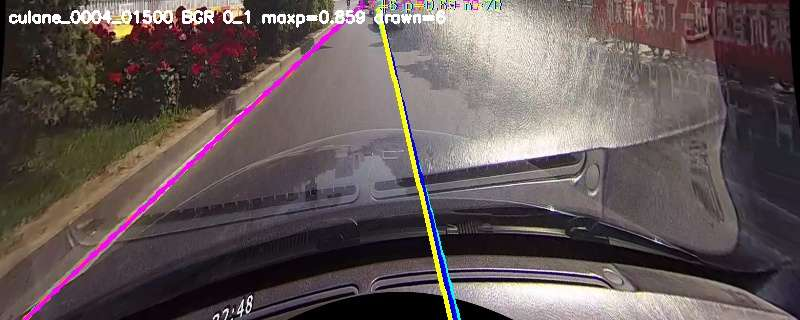

`variant_culane_0004_01500_BGR_0_255.jpg`

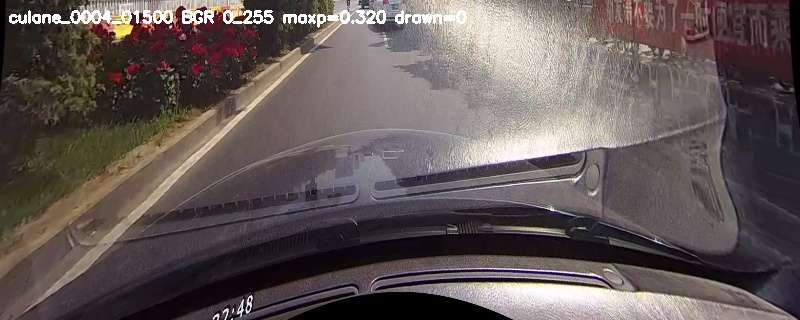

`variant_culane_0005_02010_BGR_0_1.jpg`

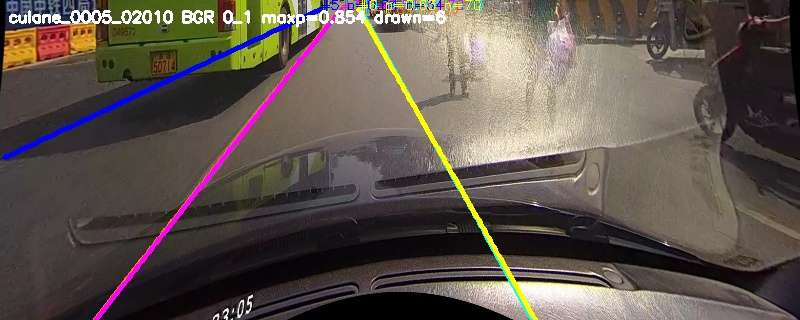

`variant_culane_0005_02010_BGR_0_255.jpg`

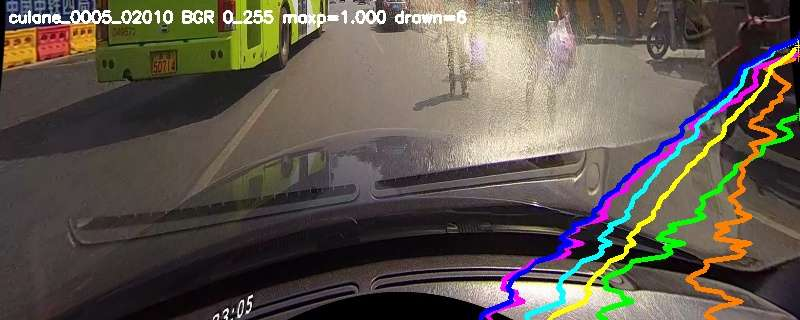

`variant_map_straight_BGR_0_1.jpg`

`variant_map_straight_BGR_0_255.jpg`

`variant_map_intersection_right_exit_BGR_0_1.jpg`

`variant_map_intersection_right_exit_BGR_0_255.jpg`

In [5]:
# 대표 결과 이미지 확인
# 먼저 CULane에서 공식 입력(BGR+0_1)이 정상적으로 선을 그리는지 본다.
image_paths = []
for sample in ["culane_0004_01500", "culane_0005_02010", "map_straight", "map_intersection_right_exit"]:
    for channel, scale in [("BGR", "0_1"), ("BGR", "0_255")]:
        p = OVERLAY_DIR / f"variant_{sample}_{channel}_{scale}.jpg"
        if p.exists():
            image_paths.append(p)

display_images(image_paths, width=520)

## 5. 우리 map scene별 batch 확인

이제 scene별로 중간 샘플 몇 장을 뽑아서 official-like 후처리 결과를 본다.

여기서 중요한 판단은 아래처럼 나눈다.

- CULane에서는 잘 그려지고 map에서는 안 그려짐: 모델/후처리 문제가 아니라 **도메인 gap** 가능성이 큼.
- straight는 그려지고 curve/intersection은 약함: pretrained CLRKDNet 단독 주행은 위험하고, fine-tuning/QAT/제어용 decoder 보완이 필요함.
- map 전체에서 충분히 그려짐: 그 다음 Pi 주행 스크립트의 decoder를 이 방식으로 교체함.

In [6]:
def sample_scene_images(scene_dir: Path, count=4):
    images = sorted([p for p in scene_dir.glob("*.jpg") if p.stat().st_size > 0])
    if not images:
        return []
    if len(images) <= count:
        return images
    idxs = np.linspace(0, len(images) - 1, count, dtype=int)
    return [images[i] for i in idxs]

scene_rows = []
scene_overlay_paths = []
# 우선 공식 입력 기준과, 비교군 0_255를 모두 본다.
variants_to_scan = [("BGR", "0_1"), ("BGR", "0_255")]

for scene_dir in sorted([p for p in LANE_RAW.iterdir() if p.is_dir()]):
    scene = scene_dir.name
    for image_idx, image_path in enumerate(sample_scene_images(scene_dir, count=4)):
        for channel, scale in variants_to_scan:
            predictions, scores, preview, elapsed_ms = run_raw(image_path, 445, channel=channel, scale=scale)
            overlay, top_table, drawn = draw_top_lanes(preview, predictions, scores, conf=DEFAULT_CONF, max_draw=6)
            out_path = OVERLAY_DIR / f"scene_{scene}_{image_idx:02d}_{channel}_{scale}.jpg"
            cv2.putText(
                overlay,
                f"{scene} {channel} {scale} maxp={scores.max():.3f} drawn={drawn}",
                (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 2,
            )
            ok = cv2.imwrite(str(out_path), overlay)
            if not ok:
                raise RuntimeError(f"failed to write overlay: {out_path}")
            scene_overlay_paths.append(out_path)
            scene_rows.append({
                "scene": scene,
                "file": image_path.name,
                "channel": channel,
                "scale": scale,
                "max_prob": float(scores.max()),
                "n_prob_ge_04": int((scores >= 0.4).sum()),
                "valid_top30_mean": float(top_table["valid_points"].mean()),
                "valid_top30_max": int(top_table["valid_points"].max()),
                "drawn_ge04": int(drawn),
                "forward_ms": elapsed_ms,
                "image": str(out_path),
            })

scene_df = pd.DataFrame(scene_rows)
scene_df.to_csv(TABLE_DIR / "map_scene_official_like_summary.csv", index=False, encoding="utf-8-sig")
summary = scene_df.groupby(["scene", "channel", "scale"], as_index=False).agg(
    images=("file", "count"),
    mean_max_prob=("max_prob", "mean"),
    mean_drawn_ge04=("drawn_ge04", "mean"),
    max_drawn_ge04=("drawn_ge04", "max"),
    mean_valid_top30=("valid_top30_mean", "mean"),
    mean_forward_ms=("forward_ms", "mean"),
)
summary.to_csv(TABLE_DIR / "map_scene_official_like_group_summary.csv", index=False, encoding="utf-8-sig")
display(summary.sort_values(["scale", "mean_drawn_ge04", "mean_max_prob"], ascending=[True, False, False]))

,scene,channel,scale,images,mean_max_prob,mean_drawn_ge04,max_drawn_ge04,mean_valid_top30,mean_forward_ms
10,intersection_right_exit,BGR,0_1,4,0.601808,3.00,3,49.283333,56.139950
16,off_center_right,BGR,0_1,4,0.300967,0.00,0,55.700000,44.281375
20,straight,BGR,0_1,4,0.241469,0.00,0,40.875000,59.261250
6,intersection_left_exit,BGR,0_1,4,0.234532,0.00,0,34.850000,95.513650
18,right_curve,BGR,0_1,4,0.167373,0.00,0,46.416667,47.469375
0,intersection,BGR,0_1,4,0.164057,0.00,0,33.466667,44.385900
8,intersection_right_entry,BGR,0_1,4,0.138537,0.00,0,46.750000,40.939400
12,left_curve,BGR,0_1,4,0.131534,0.00,0,55.416667,50.403075
14,off_center_left,BGR,0_1,4,0.103961,0.00,0,42.541667,46.239100
4,intersection_left_entry,BGR,0_1,4,0.091377,0.00,0,49.333333,69.612200


`scene_straight_00_BGR_0_1.jpg`

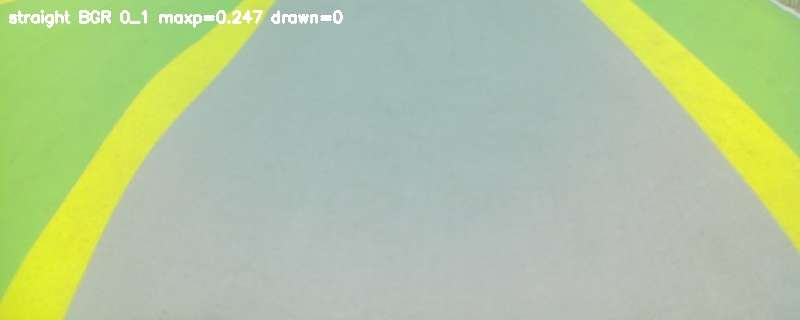

`scene_straight_01_BGR_0_1.jpg`

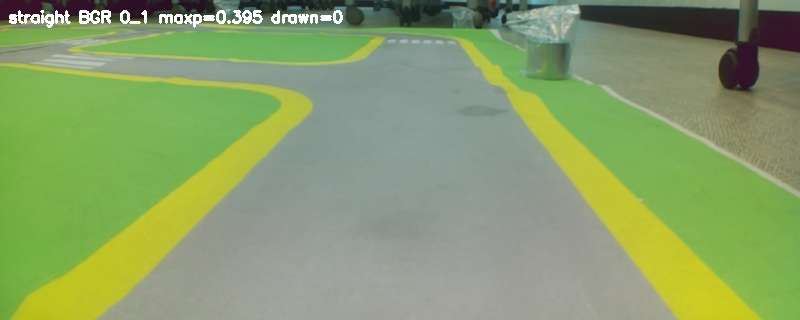

`scene_left_curve_00_BGR_0_1.jpg`

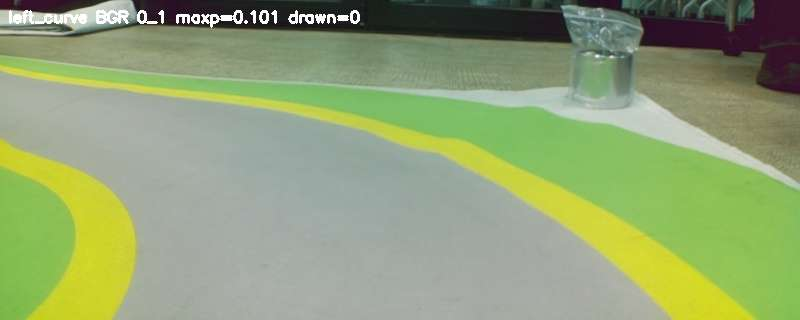

`scene_left_curve_01_BGR_0_1.jpg`

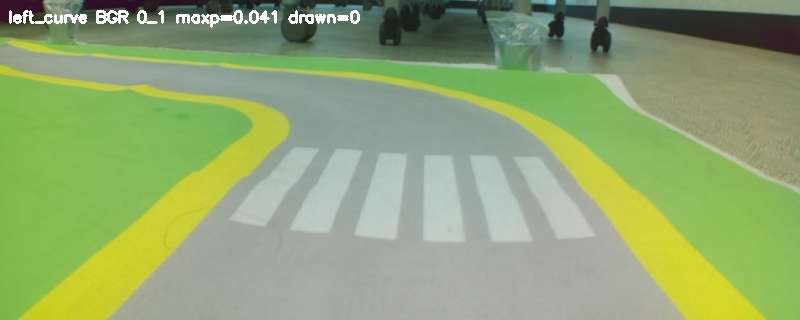

`scene_right_curve_00_BGR_0_1.jpg`

`scene_right_curve_01_BGR_0_1.jpg`

`scene_intersection_right_exit_00_BGR_0_1.jpg`

`scene_intersection_right_exit_01_BGR_0_1.jpg`

In [7]:
# scene별 overlay 일부 확인
# 필요한 scene 이름을 바꿔가며 다시 실행해도 됨.
SCENES_TO_SHOW = ["straight", "left_curve", "right_curve", "intersection_right_exit"]
VARIANT_TO_SHOW = ("BGR", "0_1")  # 필요하면 ("BGR", "0_255")로 바꿔서 비교

paths = []
for scene in SCENES_TO_SHOW:
    matched = scene_df[
        (scene_df["scene"] == scene)
        & (scene_df["channel"] == VARIANT_TO_SHOW[0])
        & (scene_df["scale"] == VARIANT_TO_SHOW[1])
    ]["image"].head(2).tolist()
    paths.extend([Path(p) for p in matched])

display_images(paths, width=520)

## 6. 검증 메모

아래 항목을 실행 결과를 보며 채운다.

- CULane 샘플에서 official-like decoder가 lane을 그리는가?
  - 결과:
- `BGR+0_1`과 `BGR+0_255` 중 어떤 쪽이 CULane에서 더 공식 결과처럼 보이는가?
  - 결과:
- 같은 조합을 map 이미지에 적용했을 때 straight / curve / intersection 중 어디까지 되는가?
  - straight:
  - curve:
  - intersection:
- 현재 판단:
  - 후처리 버그였는가?
  - 입력 스케일 혼선이 있었는가?
  - 아니면 map 도메인 gap이 주된 문제인가?
- 다음 작업:
  - Pi 주행 스크립트 decoder 수정
  - map lane fine-tuning/QAT용 라벨링 계획
  - crop/camera angle 재검토


## 7. 실행 결과 해석 메모

이번 03 노트북의 결론은 아래처럼 정리한다.

### 1. 02 노트북의 “곡선이 안 보임”은 후처리 누락 영향이 컸음

공식 CLRKDNet 후처리는 raw output의 `length`를 그대로 쓰지 않고 `length * n_strips`로 복원한다. 02에서는 이 부분이 빠져서 대부분 `length=0~1`로 해석되었고, 그래서 lane point가 1개 정도밖에 남지 않았다.

이번 03의 `length_scaling_check.csv`를 보면 같은 proposal에 대해 다음처럼 차이가 난다.

- `map_straight`: 잘못된 방식 `valid_points=1`, 공식 방식 `valid_points=55~56`
- `culane_0004_01500`: 잘못된 방식 `valid_points=1`, 공식 방식 `valid_points=70`

즉 02의 결과는 “모델이 곡선을 전혀 못 낸다”의 증거가 아니라, **우리가 공식 후처리를 덜 재현한 상태에서 본 결과**였음.

### 2. 공식 기준 입력은 `BGR + 0_1`로 보는 것이 타당함

공식 repo의 CULane pipeline은 OpenCV로 읽은 BGR 이미지에 `img.astype(np.float32) / 255.0`을 적용한다. 03에서 `BGR + 0_1` 조합으로 CULane 샘플을 보면 실제 도로 lane이 자연스럽게 그려진다.

따라서 현재 기준으로는 아래를 공식 기준 입력으로 둔다.

```text
channel = BGR
scale = 0_1
resize = 800 x 320
crop_top = CULane 기준 270, 우리 map 기준 후보값 445
score = softmax(pred[:, :2])[:, 1]
length = round(pred[:, 5] * 71)
```

### 3. 우리 map에서는 pretrained CLRKDNet의 domain gap이 큼

공식 입력 `BGR + 0_1` 기준으로 scene별 평균을 보면 대부분 confidence가 낮다.

```text
intersection_right_exit: mean max prob 0.602, mean drawn 3.0
straight:                 mean max prob 0.241, mean drawn 0.0
right_curve:              mean max prob 0.167, mean drawn 0.0
left_curve:               mean max prob 0.132, mean drawn 0.0
intersection_approach:    mean max prob 0.064, mean drawn 0.0
```

즉 일부 구간에서는 노란 선을 lane처럼 잡지만, 전체 map 주행에 쓸 만큼 안정적이지 않다. 특히 straight/curve에서 threshold 0.4 기준으로는 거의 그려지지 않는다.

### 4. `BGR + 0_255`는 점수는 높지만 신뢰하면 안 됨

`BGR + 0_255`는 우리 map에서 max probability가 크게 올라가고 선도 많이 그려진다. 그러나 overlay를 보면 선이 실제 lane을 따라가는 것이 아니라 도로 밖/엉뚱한 위치로 흔들리는 경우가 많다.

따라서 `0_255`는 “성능 개선”이 아니라 **입력 스케일을 잘못 넣어서 모델이 과하게 반응한 상태**로 해석한다. 주행용으로 채택하면 위험하다.

### 5. 현재 판단

CLRKDNet ONNX 자체는 죽은 모델이 아니다. CULane 샘플에서는 공식 후처리와 공식 입력으로 lane이 그려진다. 그러나 우리 프로젝트 map은 실제 도로 이미지와 다르게 회색 바닥, 노란 굵은 선, 낮은 카메라 시점, 교차로/횡단보도 패턴이 많다. 그래서 pretrained CLRKDNet을 그대로 주행 제어에 쓰기에는 도메인 gap이 크다.

현재 결론은 다음과 같다.

- 후처리: 02 방식은 수정 필요. 공식 후처리 기준으로 교체해야 함.
- 입력: `BGR + 0_1`을 기준으로 유지해야 함.
- pretrained CLRKDNet: CULane에서는 정상, 우리 map에서는 불안정.
- 다음 단계: pretrained 모델을 그대로 튜닝해서 주행하기보다, 우리 map 데이터로 fine-tuning/QAT 가능성을 검토해야 함. 다만 fine-tuning에는 lane annotation이 필요하므로, 자동/반자동 라벨링 전략을 먼저 설계해야 함.


In [8]:
print("03 notebook outputs")
print("tables:", TABLE_DIR)
print("overlays:", OVERLAY_DIR)
print("\n판단 기준:")
print("1) CULane에서 안 그려지면 후처리/입력 재현이 아직 틀린 것")
print("2) CULane에서 그려지고 map에서 안 그려지면 도메인 gap")
print("3) map straight만 되고 curve가 안 되면 pretrained lane model 단독 주행은 위험")

03 notebook outputs
tables: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\phase3_lane_experiments\outputs\03_official_inference_reproduction\tables
overlays: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\phase3_lane_experiments\outputs\03_official_inference_reproduction\overlays

판단 기준:
1) CULane에서 안 그려지면 후처리/입력 재현이 아직 틀린 것
2) CULane에서 그려지고 map에서 안 그려지면 도메인 gap
3) map straight만 되고 curve가 안 되면 pretrained lane model 단독 주행은 위험
